## Rolling Regression

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

import pandas_datareader as pdr

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

In [8]:
factors = pdr.get_data_famafrench('F-F_Research_Data_Factors', start='1-1-1926')[0]
industries = pdr.get_data_famafrench('10_Industry_Portfolios', start='1-1-1926')[0]

In [9]:
factors

,Mkt-RF,SMB,HML,RF
Date,,,,
1926-07,2.89,-2.55,-2.39,0.22
1926-08,2.64,-1.14,3.81,0.25
1926-09,0.38,-1.36,0.05,0.23
1926-10,-3.27,-0.14,0.82,0.32
1926-11,2.54,-0.11,-0.61,0.31
...,...,...,...,...
2026-01,1.03,2.13,3.82,0.30
2026-02,-1.17,0.23,2.71,0.28
2026-03,-5.18,0.42,3.41,0.29


In [11]:
industries

,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
Date,,,,,,,,,,
1926-07,1.44,13.90,4.70,-1.14,2.90,0.83,0.12,1.85,7.04,2.14
1926-08,3.99,3.70,2.80,3.43,2.66,2.17,-0.72,4.17,-1.70,4.35
1926-09,1.15,4.98,1.17,-3.30,-0.39,2.42,0.21,0.69,2.05,0.31
1926-10,-1.24,-8.39,-3.65,-0.78,-4.58,-0.11,-2.29,-0.57,-3.27,-2.85
1926-11,5.21,-0.17,4.27,0.01,4.71,1.63,6.45,5.43,4.40,2.13
...,...,...,...,...,...,...,...,...,...,...
2026-01,7.00,-2.44,10.65,13.80,-0.84,3.40,4.99,0.52,2.86,-0.81
2026-02,7.11,-4.64,7.28,8.69,-4.90,4.04,-1.78,4.63,9.90,-0.89
2026-03,-8.05,-8.03,-9.61,12.85,-4.73,-2.61,-4.31,-7.23,-2.05,-4.93


In [12]:
endog = industries.HiTec - factors.RF.values
exog = sm.add_constant(factors['Mkt-RF'])
rols = RollingOLS(endog, exog, window=60)
rres = rols.fit()
params = rres.params
print(params.head())
print(params.tail())

         const  Mkt-RF
Date                  
1926-07    NaN     NaN
1926-08    NaN     NaN
1926-09    NaN     NaN
1926-10    NaN     NaN
1926-11    NaN     NaN
            const    Mkt-RF
Date                       
2026-01  0.245018  1.190446
2026-02  0.206159  1.201231
2026-03  0.274021  1.202915
2026-04  0.329293  1.240708
2026-05  0.429938  1.256876


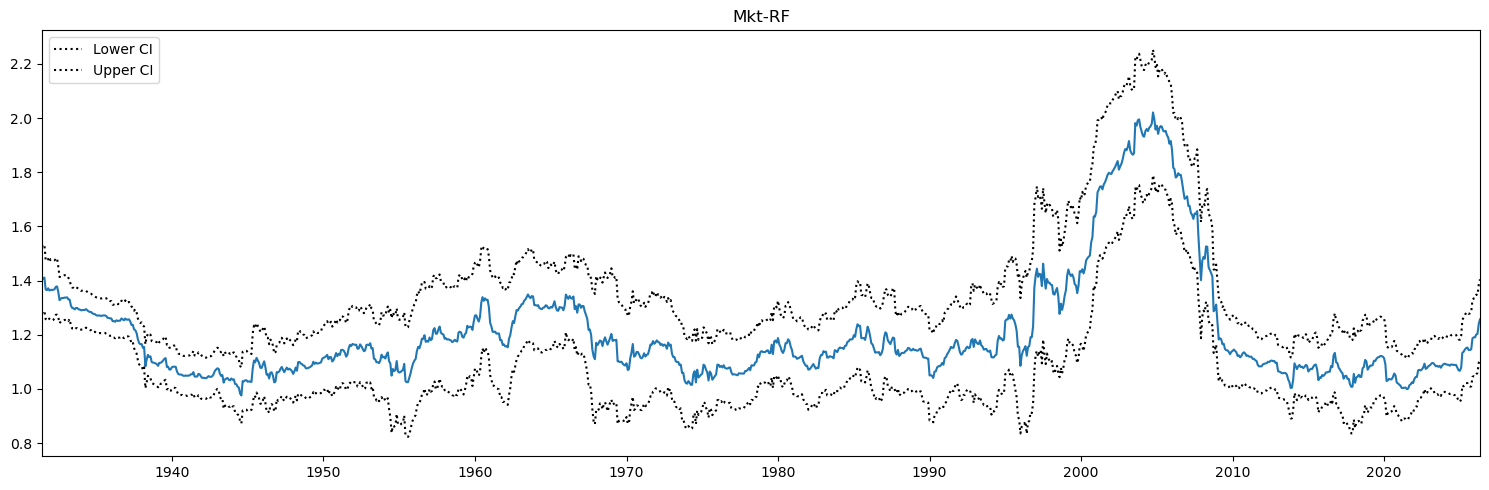

In [14]:
rres.plot_recursive_coefficient(variables=['Mkt-RF'], figsize=(15,5));

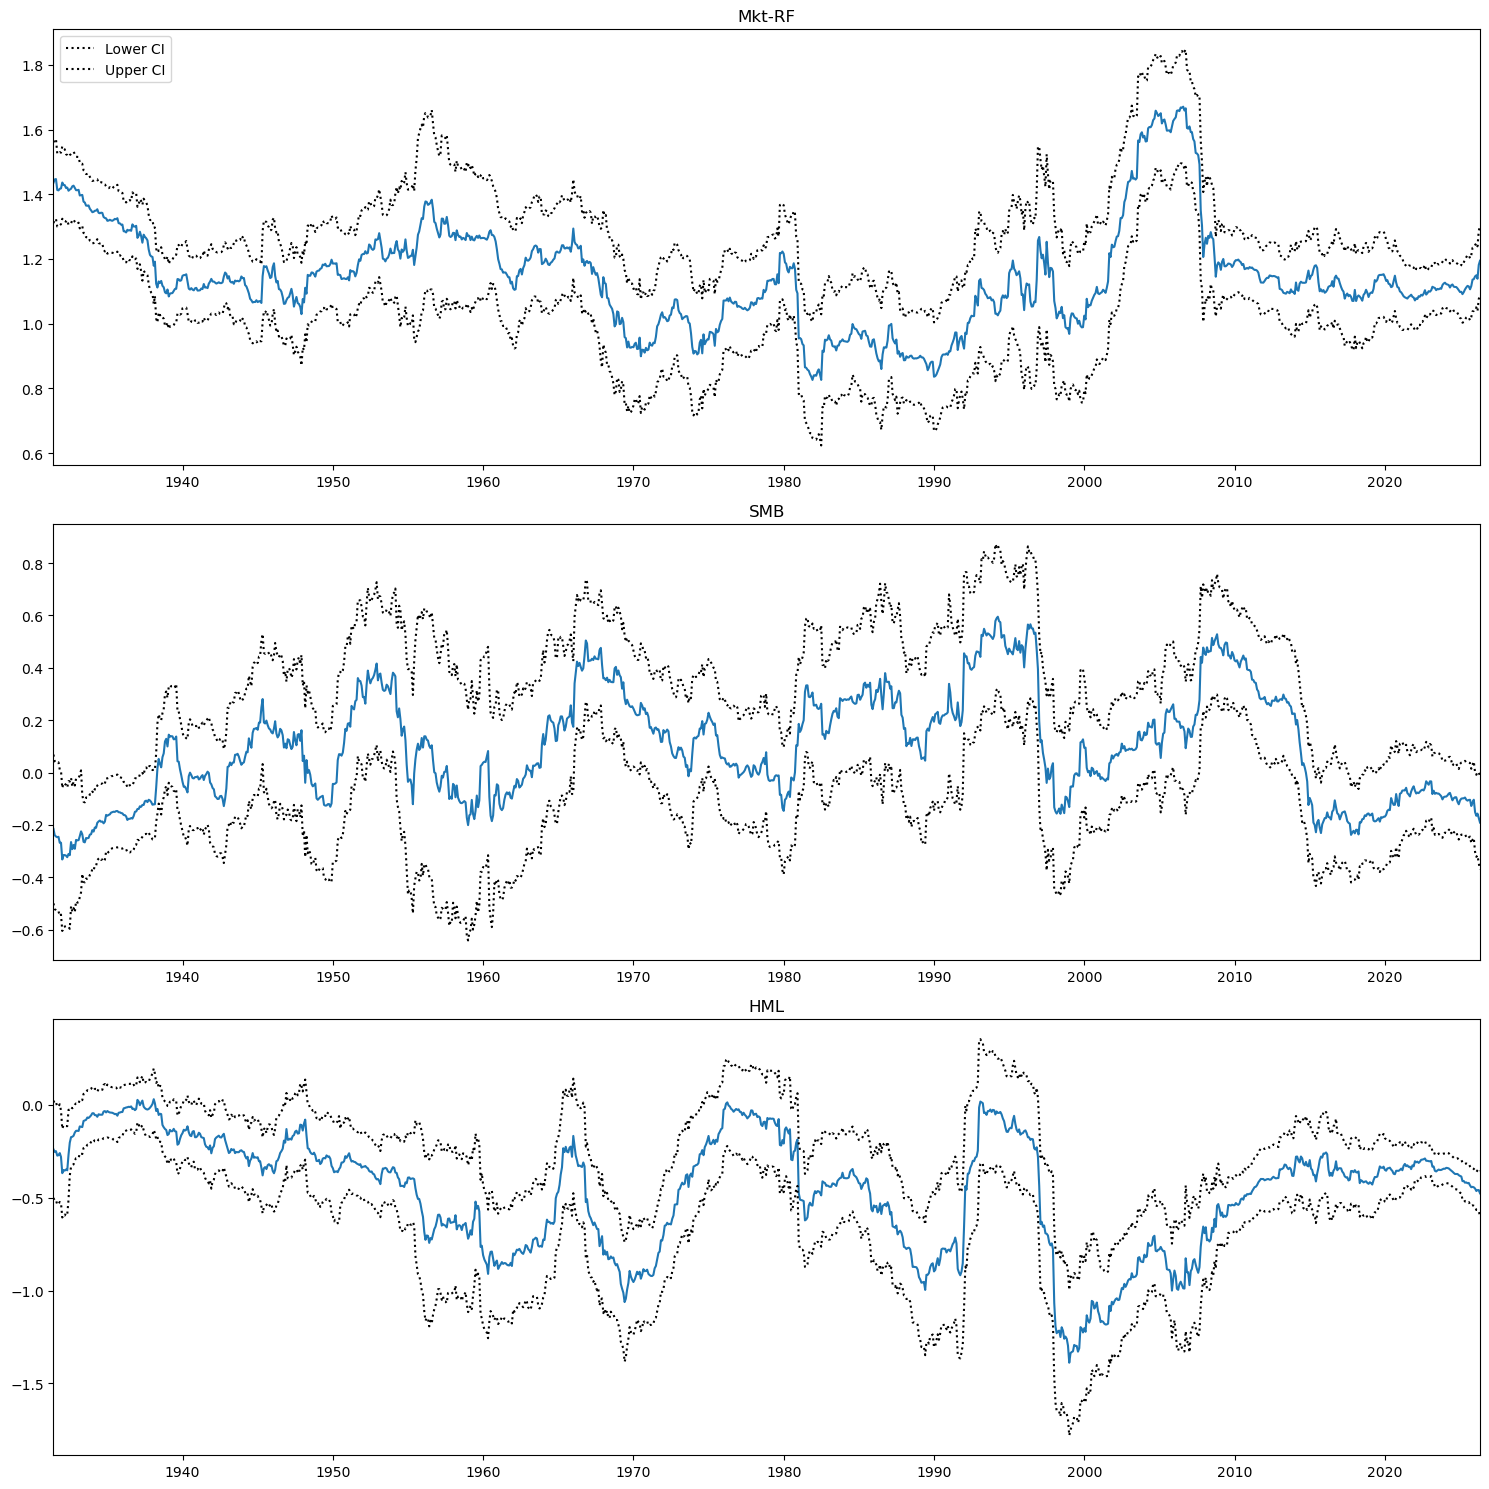

In [17]:
exog_vars = ['Mkt-RF', 'SMB', 'HML']
exog = sm.add_constant(factors[exog_vars])
rols = RollingOLS(endog, exog, window=60)
rres = rols.fit()
rres.plot_recursive_coefficient(variables=exog_vars, figsize=(15,15));